# E-Commerce Sales & Customer Analytics

**Business question:** where is revenue coming from, which products and
customers drive it, and where should the business focus to grow it further?

Dataset: one fiscal year (2025) of orders for a mid-size online retailer
selling electronics, office supplies, furniture, home goods, and
accessories through an 8-person inside sales team. Synthetically generated
(see `data/generate_data.py`) with realistic seasonality, order statuses,
and customer/employee variation baked into the simulation.

In [1]:
import json
import sqlite3

import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import pandas as pd

DATA = "../data"

customers = pd.read_csv(f"{DATA}/customers.csv", parse_dates=["signup_date"])
employees = pd.read_csv(f"{DATA}/employees.csv")
products = pd.read_csv(f"{DATA}/products.csv")
orders = pd.read_csv(f"{DATA}/orders.csv", parse_dates=["order_date"])
order_items = pd.read_csv(f"{DATA}/order_items.csv")

# Categorical palette (fixed order, colorblind-validated) — see dataviz skill
BLUE, ORANGE, AQUA, YELLOW, MAGENTA, GREEN, VIOLET, RED = (
    "#2a78d6", "#eb6834", "#1baf7a", "#eda100",
    "#e87ba4", "#008300", "#4a3aa7", "#e34948",
)
PALETTE = [BLUE, ORANGE, AQUA, YELLOW, MAGENTA, GREEN, VIOLET, RED]
plt.rcParams.update({
    "figure.facecolor": "#fcfcfb", "axes.facecolor": "#fcfcfb",
    "axes.edgecolor": "#c3c2b7", "axes.labelcolor": "#0b0b0b",
    "text.color": "#0b0b0b", "xtick.color": "#52514e", "ytick.color": "#52514e",
    "axes.grid": True, "grid.color": "#e1e0d9", "grid.linewidth": 0.8,
    "font.size": 11, "axes.spines.top": False, "axes.spines.right": False,
}.items())

items = order_items.merge(products, on="product_id")
items["revenue"] = items["quantity"] * items["price"]
items["profit"] = items["quantity"] * (items["price"] - items["cost"])

full = items.merge(orders, on="order_id").merge(customers, on="customer_id").merge(
    employees, on="employee_id"
)
completed = full[full["status"] == "Completed"].copy()
completed["month"] = completed["order_date"].dt.to_period("M").astype(str)

print(f"{len(orders):,} orders | {len(order_items):,} line items | "
      f"{len(customers):,} customers | {len(products)} products")

1,800 orders | 4,567 line items | 200 customers | 20 products


## 1. Order funnel & overall KPIs

In [2]:
status_counts = orders["status"].value_counts()
status_pct = (status_counts / len(orders) * 100).round(1)

order_revenue = completed.groupby("order_id")["revenue"].sum()
total_revenue = completed["revenue"].sum()
total_profit = completed["profit"].sum()
gross_margin_pct = total_profit / total_revenue * 100
aov = order_revenue.mean()
total_orders = completed["order_id"].nunique()
total_customers = completed["customer_id"].nunique()
cancel_return_pct = 100 - status_pct.get("Completed", 0)

kpis = {
    "total_revenue": round(total_revenue, 2),
    "total_profit": round(total_profit, 2),
    "gross_margin_pct": round(gross_margin_pct, 1),
    "avg_order_value": round(aov, 2),
    "total_orders": int(total_orders),
    "total_customers": int(total_customers),
    "completed_pct": round(status_pct.get("Completed", 0), 1),
    "cancelled_pct": round(status_pct.get("Cancelled", 0), 1),
    "returned_pct": round(status_pct.get("Returned", 0), 1),
}
for k, v in kpis.items():
    print(f"{k:>18}: {v}")

     total_revenue: 757335.95
      total_profit: 337329.95
  gross_margin_pct: 44.5
   avg_order_value: 465.48
      total_orders: 1627
   total_customers: 200
     completed_pct: 90.4
     cancelled_pct: 5.8
      returned_pct: 3.8


## 2. Monthly revenue trend — the Q4 holiday ramp

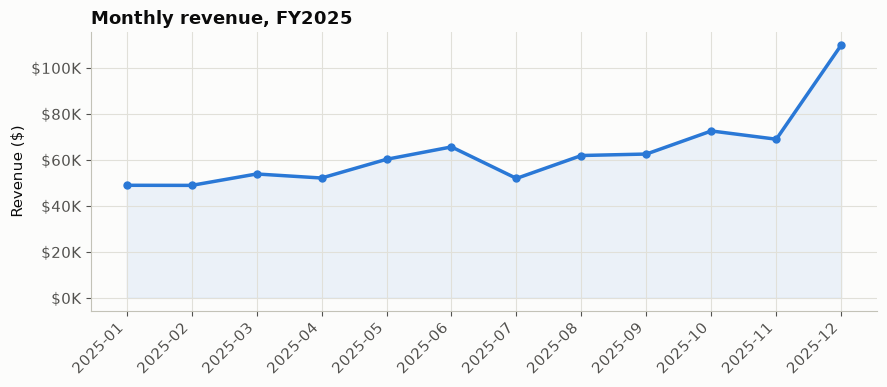

Nov+Dec revenue: $178,871 (23.6% of FY2025 total)


In [3]:
monthly = completed.groupby("month").agg(revenue=("revenue", "sum"), orders=("order_id", "nunique"))
monthly = monthly.reset_index()

fig, ax = plt.subplots(figsize=(9, 4))
ax.plot(monthly["month"], monthly["revenue"], color=BLUE, linewidth=2.5, marker="o", markersize=5)
ax.fill_between(monthly["month"], monthly["revenue"], color=BLUE, alpha=0.08)
ax.set_title("Monthly revenue, FY2025", loc="left", fontweight="bold")
ax.set_ylabel("Revenue ($)")
ax.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f"${x/1000:,.0f}K"))
plt.setp(ax.get_xticklabels(), rotation=45, ha="right")
fig.tight_layout()
fig.savefig("../assets/monthly_revenue.png", dpi=150)
plt.show()

nov_dec = monthly[monthly["month"].isin(["2025-11", "2025-12"])]["revenue"].sum()
q4_share = nov_dec / total_revenue * 100
print(f"Nov+Dec revenue: ${nov_dec:,.0f} ({q4_share:.1f}% of FY2025 total)")

## 3. Category & product performance

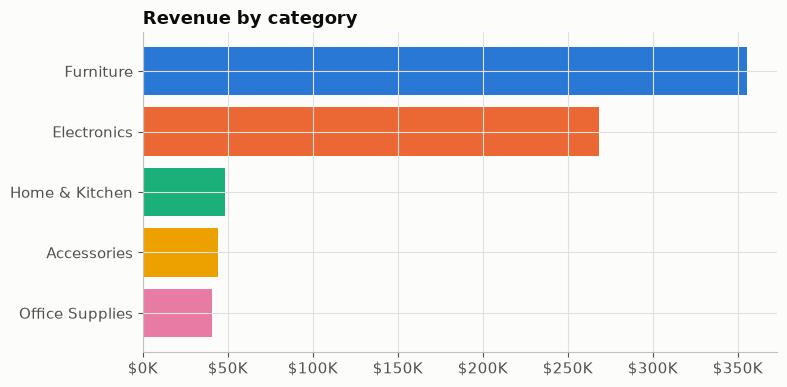

,revenue,profit,units,margin_pct
category,,,,
Furniture,355345.30,149769.30,1470,42.1
Electronics,268614.06,116727.06,2594,43.5
Home & Kitchen,48584.15,24836.15,1085,51.1
Accessories,44312.93,25331.93,1007,57.2
Office Supplies,40479.51,20665.51,1049,51.1


In [4]:
by_category = (
    completed.groupby("category")
    .agg(revenue=("revenue", "sum"), profit=("profit", "sum"), units=("quantity", "sum"))
    .assign(margin_pct=lambda d: (d["profit"] / d["revenue"] * 100).round(1))
    .sort_values("revenue", ascending=False)
)

fig, ax = plt.subplots(figsize=(8, 4))
colors = PALETTE[: len(by_category)]
ax.barh(by_category.index[::-1], by_category["revenue"][::-1], color=colors[::-1])
ax.set_title("Revenue by category", loc="left", fontweight="bold")
ax.xaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f"${x/1000:,.0f}K"))
fig.tight_layout()
fig.savefig("../assets/category_revenue.png", dpi=150)
plt.show()

by_category

In [5]:
top_products = (
    completed.groupby(["product_name", "category"])
    .agg(revenue=("revenue", "sum"), profit=("profit", "sum"), units=("quantity", "sum"))
    .sort_values("revenue", ascending=False)
    .head(10)
    .reset_index()
)
top_products["margin_pct"] = (top_products["profit"] / top_products["revenue"] * 100).round(1)
top_products

,product_name,category,revenue,profit,units,margin_pct
0,Standing Desk,Furniture,139196.52,57416.52,348,41.2
1,27-inch Monitor,Electronics,82106.43,30341.43,357,37.0
2,Ergonomic Office Chair,Furniture,77996.88,32756.88,312,42.0
3,Filing Cabinet,Furniture,77035.72,32095.72,428,41.7
4,Bookshelf,Furniture,61116.18,27500.18,382,45.0
5,Portable SSD,Electronics,53295.90,21315.90,410,40.0
6,Noise-Canceling Headset,Electronics,45716.19,22094.19,381,48.3
7,Mechanical Keyboard,Electronics,33296.30,15536.30,370,46.7
8,Coffee Maker,Home & Kitchen,28956.38,13752.38,362,47.5
9,Webcam,Electronics,26771.43,13205.43,357,49.3


## 4. Customer value concentration

In [6]:
customer_revenue = completed.groupby("customer_id")["revenue"].sum().sort_values(ascending=False)
n = len(customer_revenue)
quartile_size = n // 4
top_quartile_share = customer_revenue.iloc[:quartile_size].sum() / customer_revenue.sum() * 100
top_10pct_share = customer_revenue.iloc[: n // 10].sum() / customer_revenue.sum() * 100

print(f"Top 25% of customers ({quartile_size} of {n}) drive "
      f"{top_quartile_share:.1f}% of revenue")
print(f"Top 10% of customers ({n // 10} of {n}) drive {top_10pct_share:.1f}% of revenue")

top10 = (
    completed.groupby(["customer_id", "first_name", "last_name", "state"])
    .agg(revenue=("revenue", "sum"), orders=("order_id", "nunique"))
    .sort_values("revenue", ascending=False)
    .head(10)
    .reset_index()
)
top10["customer_name"] = top10["first_name"] + " " + top10["last_name"]
top10[["customer_name", "state", "orders", "revenue"]]

Top 25% of customers (50 of 200) drive 41.2% of revenue
Top 10% of customers (20 of 200) drive 19.7% of revenue


,customer_name,state,orders,revenue
0,Samantha Allen,IL,18,8868.31
1,Christopher Wilson,WI,13,8609.45
2,Joshua Johnson,IL,15,8569.09
3,Michael King,WI,13,8229.38
4,Amanda Jackson,IL,12,8042.39
5,Daniel Hall,WI,11,7902.42
6,Sarah Lee,IL,14,7899.43
7,Matthew Young,WI,15,7722.34
8,Daniel Walker,IL,10,7660.45
9,Emily Jackson,WI,13,7465.35


## 5. Sales rep performance

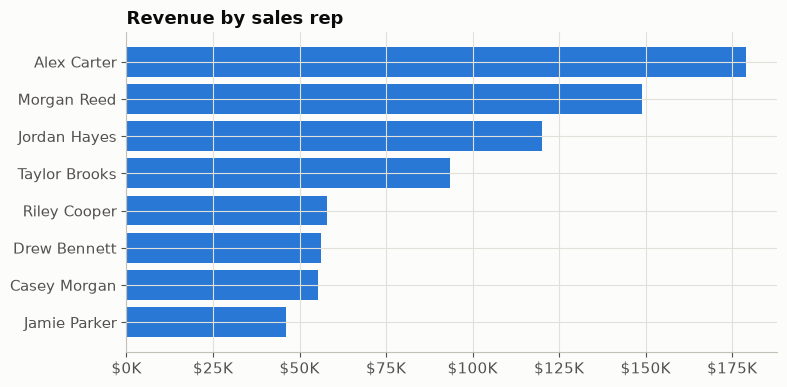

Alex Carter closes 23.6% of completed revenue; the lowest performer closes 6.1%.


In [7]:
by_rep = (
    completed.groupby("employee_name")
    .agg(revenue=("revenue", "sum"), orders=("order_id", "nunique"))
    .assign(avg_order_value=lambda d: (d["revenue"] / d["orders"]).round(2))
    .sort_values("revenue", ascending=False)
)

fig, ax = plt.subplots(figsize=(8, 4))
ax.barh(by_rep.index[::-1], by_rep["revenue"][::-1], color=BLUE)
ax.set_title("Revenue by sales rep", loc="left", fontweight="bold")
ax.xaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f"${x/1000:,.0f}K"))
fig.tight_layout()
fig.savefig("../assets/rep_revenue.png", dpi=150)
plt.show()

top_rep = by_rep.index[0]
top_rep_share = by_rep["revenue"].iloc[0] / by_rep["revenue"].sum() * 100
bottom_rep_share = by_rep["revenue"].iloc[-1] / by_rep["revenue"].sum() * 100
print(f"{top_rep} closes {top_rep_share:.1f}% of completed revenue; "
      f"the lowest performer closes {bottom_rep_share:.1f}%.")

## 6. Export summary for the dashboard

In [8]:
quartile_labels = pd.qcut(
    (-customer_revenue).rank(method="first"), 4, labels=[1, 2, 3, 4]
)
quartile_revenue_pct = (
    customer_revenue.groupby(quartile_labels).sum() / customer_revenue.sum() * 100
).round(1).tolist()

summary = {
    "kpis": kpis,
    "status_counts": status_counts.to_dict(),
    "monthly": monthly.to_dict(orient="records"),
    "categories": by_category.reset_index().to_dict(orient="records"),
    "top_products": top_products.to_dict(orient="records"),
    "top_customers": top10[["customer_name", "state", "orders", "revenue"]].to_dict(orient="records"),
    "reps": by_rep.reset_index().to_dict(orient="records"),
    "customer_concentration": {
        "top_quartile_share_pct": round(top_quartile_share, 1),
        "top_10pct_share_pct": round(top_10pct_share, 1),
        "quartile_revenue_pct": quartile_revenue_pct,
    },
}
with open("../assets/dashboard_summary.json", "w") as f:
    json.dump(summary, f, indent=2)
print("Wrote assets/dashboard_summary.json")

Wrote assets/dashboard_summary.json
